In [1]:
import os

from charset_normalizer.cli import query_yes_no

os.environ["SCIPY_ARRAY_API"] = "1"

import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix



In [2]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance", # categorical
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

selected_features = [
    'VWF_HUMAN',
    'CRP_HUMAN',
    'AACT_HUMAN',
    'B2MG_HUMAN',
    'IBP3_HUMAN',
    'FIBG_HUMAN',
    'CYTC_HUMAN',
    'VCAM1_HUMAN',
    'LBP_HUMAN',
    'A2GL_HUMAN'
]

In [3]:
continuous_clinical_columns.extend(selected_features)

In [4]:

def preprocess_design_matrix(design_matrix):

    # design_matrix = design_matrix[
    #     ((design_matrix['Sepsis Diagnosis Probability'] >= 0.8) | 
    #     (design_matrix['Sepsis Diagnosis Probability'] <= 0.50))
    # ].copy()

    design_matrix['group'] = 1

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [5]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix.annotate()     


In [6]:
ms_data = pd.read_csv(
    "../0_data/proteins_test_filtered.tsv"
    , sep="\t"
)

In [7]:
design_matrix = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

In [8]:
ms_data_test = pd.read_csv(
    "../0_data/proteins_val_filtered.tsv"
    , sep="\t"
)
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_validation.tsv",
    sep='\t'
)

In [9]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['future_deterioration'] = np.where(
    design_matrix['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix['sofa_score_increase_day3'] > 1, 1, 0
    )
)

design_matrix_test['future_deterioration'] = np.where(
    design_matrix_test['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix_test['sofa_score_increase_day3'] > 1, 1, 0
    )
)

In [10]:
design_matrix_train = preprocess_design_matrix(design_matrix)

quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [11]:
quant_matrix_train_df = quant_matrix_train.to_df()
quant_matrix_train_df = quant_matrix_train_df[quant_matrix_train_df['ProteinLabel'].isin(selected_features)]

In [12]:
qm_filtered_train = (

    QuantMatrix(
        quantification_file=quant_matrix_train_df,
        design_matrix_file=design_matrix_train
    )

)

In [13]:
training_data, y = qm_filtered_train.to_ml(feature_column="ProteinLabel")

In [14]:
training_data = training_data.join(
    design_matrix_train.set_index("injection")
)

In [15]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer


In [16]:
design_matrix_test = preprocess_design_matrix(design_matrix_test)

quant_matrix_test = preprocess_data(ms_data_test, design_matrix=design_matrix_test)

In [17]:
quant_matrix_test_df = quant_matrix_test.to_df()
quant_matrix_test_df = quant_matrix_test_df[quant_matrix_test_df['ProteinLabel'].isin(selected_features)]

In [18]:
qm_filtered_test = (
    
    QuantMatrix(
        quantification_file=quant_matrix_test_df,
        design_matrix_file=design_matrix_test
    )
    
)

In [19]:
testing_data, y_test = qm_filtered_test.to_ml(feature_column="ProteinLabel")

In [20]:
testing_data = testing_data.join(
    design_matrix_test.set_index("injection")
)

In [21]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

clinical_scaler = StandardScaler()
protein_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])


In [22]:
training_data[selected_features]

,VWF_HUMAN,CRP_HUMAN,AACT_HUMAN,B2MG_HUMAN,IBP3_HUMAN,FIBG_HUMAN,CYTC_HUMAN,VCAM1_HUMAN,LBP_HUMAN,A2GL_HUMAN
SA_BOX_9-159_S1-D9_1_6172,-0.861609,-0.832145,-1.522666,-0.396967,0.871086,-0.824617,-0.984431,-0.750702,-0.942249,-2.180324
SA_BOX_7-267_S4-H8_1_5971,3.443652,1.164734,1.136805,1.308009,1.218496,1.277020,1.364034,0.670960,1.475495,0.518575
SA_BOX_15-464_S4-G9_1_6763,-0.804806,0.899652,0.517773,-1.113088,0.116857,1.108040,-1.312836,-1.421451,0.904487,1.349402
SA_BOX_2-1700_S2-D11_1_6971,-0.417686,0.697986,0.292720,-0.008170,-1.498996,0.540939,0.215088,-0.264485,-0.060581,0.903033
SA_BOX_7-1728_S4-F9_1_5977,-0.460148,-0.558110,-0.058111,0.514374,0.440166,0.288371,0.994396,0.179048,0.526041,-0.700227
...,...,...,...,...,...,...,...,...,...,...
SA_BOX_6-659_S2-F10_1_5887,-0.081071,0.122692,-0.299779,1.346329,1.365108,-0.412568,1.595662,0.767814,0.294558,0.465016
SA_BOX_7-2061_S4-H5_1_5946,-0.449211,0.018225,-0.512041,-0.442658,0.946659,-0.233424,-1.845724,-0.640151,0.819934,0.773169
SA_BOX_2-764_S2-G2_1_6901,0.037911,0.712995,0.542622,0.849833,0.372905,1.110575,1.146930,0.547027,-0.000880,0.746386
SA_BOX_6-774_S2-D10_1_5885,0.623011,1.253079,0.701872,-0.104324,0.461945,0.300801,-0.278259,1.354294,2.188609,2.305890


In [23]:
training_data = training_data.reset_index(drop=True)

In [24]:
testing_data = testing_data.reset_index(drop=True)

In [25]:
from dfmodel import DigitalFamilyBinary

df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    neighbor_metric="euclidean",
    bootstrap_iterations=1000,
)

df_estimator.fit(training_data, features=selected_features)

In [26]:
training_data['Sepsis Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=False)
training_data['Infection Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="verified_infection", bootstrap=False)
training_data['Future Organ Dysfunction'] = df_estimator.predict(training_data, features=selected_features, target_column="future_deterioration", bootstrap=False)
training_data['30 Day Mortality'] = df_estimator.predict(training_data, features=selected_features, target_column="survival_30_day", bootstrap=False)

In [27]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_

positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

In [28]:
display_columns = [
    "Sepsis Rates",
    "Infection Rates",
    "Future Organ Dysfunction",
    "30 Day Mortality",
]

In [29]:

def networkx_to_igraph(nx_graph):
    ig_graph = ig.Graph(directed=nx_graph.is_directed())
    ig_graph.add_vertices(list(nx_graph.nodes()))
    ig_graph.add_edges(list(nx_graph.edges()))

    # Optional: transfer node and edge attributes
    for node, attrs in nx_graph.nodes(data=True):
        for attr, value in attrs.items():
            ig_graph.vs[node][attr] = value

    for i, (u, v, attrs) in enumerate(nx_graph.edges(data=True)):
        for attr, value in attrs.items():
            ig_graph.es[i][attr] = value

    return ig_graph


In [30]:
import igraph as ig
import leidenalg as la

h = networkx_to_igraph(G)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:388: SyntaxWarning: invalid escape sequence '\m'
  """ Implements modularity. This quality function is well-defined only for positive edge weights.
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:761: SyntaxWarning: invalid escape sequence '\m'
  """ Implements Reichardt and Bornholdt's Potts model with a configuration null model.
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:7: SyntaxWarning: invalid escape sequence '\g'
  """ Class for doing community detection using the Leiden algorithm.
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leide

In [31]:
partition = la.find_partition(
    h,
    la.RBConfigurationVertexPartition,
    resolution_parameter = 0.5
)

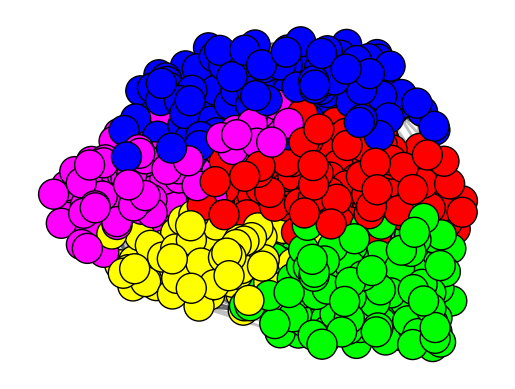

In [32]:

fig, ax = plt.subplots()

ig.plot(partition, target=ax)

In [33]:
training_data['Community'] = [partition.membership[v.index] for v in h.vs]

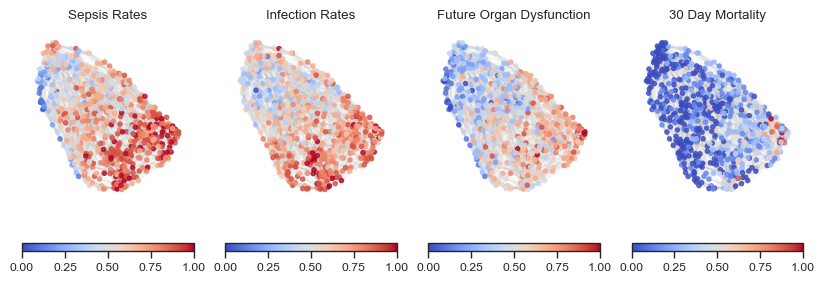

In [34]:
import matplotlib.pyplot as plt
sns.set_theme(font="Arial", style="white", context="paper")


fig, axs = plt.subplots(
    nrows=1,
    ncols=4
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    node_colors = [color_map[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)

    sm = plt.cm.ScalarMappable(cmap="coolwarm")
    cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

    #cbar = fig.colorbar(ax=axs[i])

fig.set_size_inches((8.27, 3))
plt.tight_layout()

(np.float64(-836.5110076904297),
 np.float64(984.0015472412109),
 np.float64(-632.7523773193359),
 np.float64(647.5377166748046))

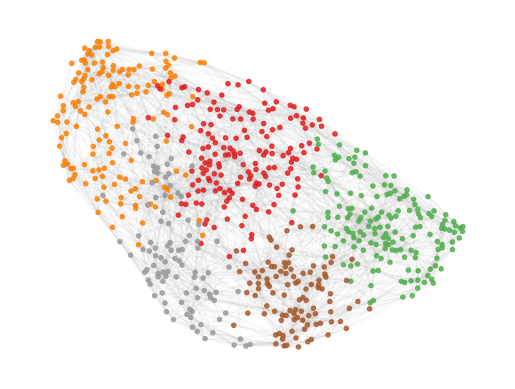

In [35]:
import matplotlib.pyplot as plt
sns.set_theme(font="Arial", style="white", context="paper")

fig, ax = plt.subplots()

values = training_data['Community'].to_list()

cmap = sns.color_palette("Set1", training_data['Community'].unique().shape[0])
color_map = dict(zip(training_data.index, values))
node_colors = [color_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="Set1", alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=ax)

ax.axis("off")

# sm = plt.cm.ScalarMappable(cmap="coolwarm")
# cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

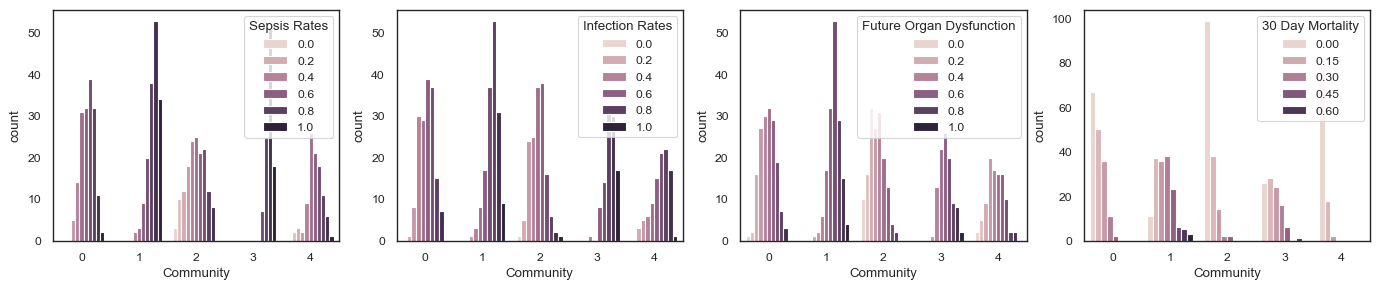

In [36]:

fig, axs = plt.subplots(
    nrows=1,
    ncols=4
)

for i, col in enumerate(display_columns):

    sns.countplot(
        data=training_data,
        x="Community",
        hue=col,
        ax=axs[i]
    )

fig.set_size_inches((17, 3))

In [37]:
training_data['Safe Zone'] = np.where(training_data['Community'] == 3, 1, 0)

(np.float64(-836.5110076904297),
 np.float64(984.0015472412109),
 np.float64(-632.7523773193359),
 np.float64(647.5377166748046))

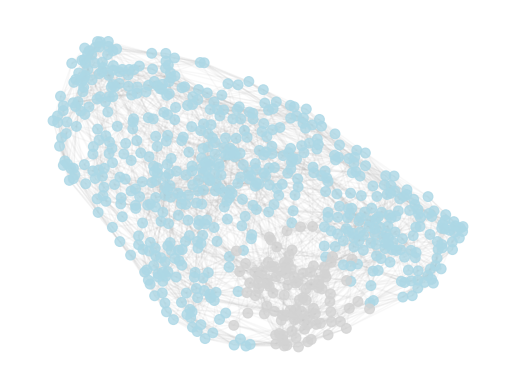

In [38]:
import matplotlib.pyplot as plt
sns.set_theme(font="Arial", style="white", context="paper")

fig, ax = plt.subplots()

values = np.where(training_data['Community'] == 3, 1, 0)

cmap = sns.color_palette(["#ADD8E6", "#D3D3D3"])
color_map = dict(zip(training_data.index, values))

node_colors = [cmap[color_map[i]] for i in G.nodes()]

nx.draw_networkx_nodes(G, positions, node_size=50, node_color=node_colors, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=ax)

ax.axis("off")

In [39]:
testing_data['Sepsis Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=False)
testing_data['Infection Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="verified_infection", bootstrap=False)
testing_data['Future Organ Dysfunction'] = df_estimator.predict(testing_data, features=selected_features, target_column="future_deterioration", bootstrap=False)
testing_data['30 Day Mortality'] = df_estimator.predict(testing_data, features=selected_features, target_column="survival_30_day", bootstrap=False)

<Axes: xlabel='Future Organ Dysfunction', ylabel='count'>

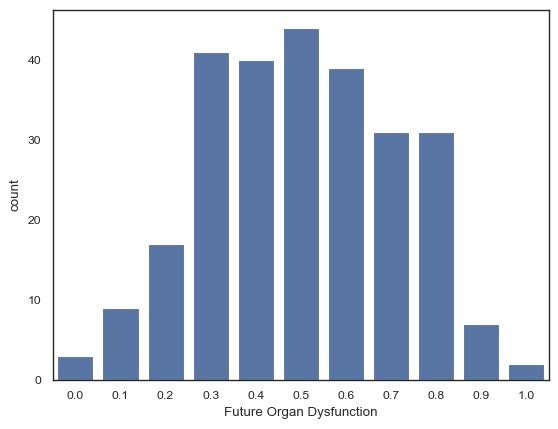

In [40]:
sns.countplot(
    data=testing_data,
    x="Future Organ Dysfunction",
)

In [41]:
future_organ_mean = testing_data['Future Organ Dysfunction'].mean()
future_organ_std = testing_data['Future Organ Dysfunction'].std()

In [42]:
organ_dys_cutoff = future_organ_mean - future_organ_std

In [43]:
training_data[training_data['Future Organ Dysfunction'] < organ_dys_cutoff]['survival_30_day'].value_counts()

survival_30_day
0    89
1     5
Name: count, dtype: int64

<Axes: xlabel='30 Day Mortality', ylabel='count'>

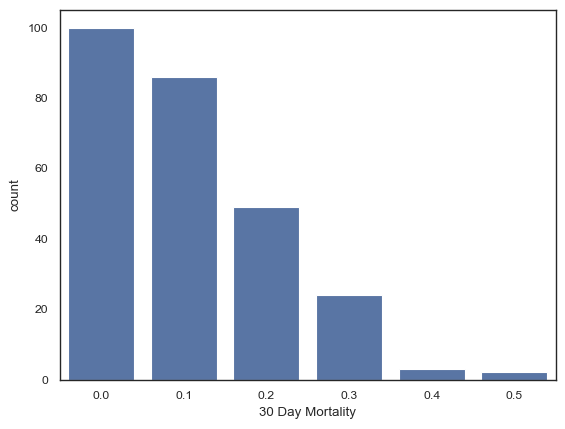

In [44]:
sns.countplot(
    data=testing_data,
    x="30 Day Mortality",
)

In [45]:
def goal(graph, node):

    return all(
         graph.nodes[n]['Future Organ Dysfunction'] < organ_dys_cutoff for n in graph.neighbors(node)
    )
    # return all(
    #     graph.nodes[n]['Safe Zone'] == 1.0 for n in graph.neighbors(node)
    # )

def heuristic(graph, u, v):

    u_data = np.array([graph.nodes[u][col] for col in selected_features])
    v_data = np.array([graph.nodes[v][col] for col in selected_features])

    return np.linalg.norm(u_data - v_data) # returns Euclidean distance between target and source


def find_path(graph, source):

    visited = set()

    queue = [(0, source, [source])]

    while queue:

        queue.sort()

        cost, current, path = queue.pop(0)

        if goal(graph, current):

            return path

        visited.add(current)
        for n in graph.neighbors(current):
            if n not in visited:
                h = heuristic(graph, n, source)
                queue.append((cost + h, n, path + [n]))

    return []



In [46]:
testing_data[testing_data['Future Organ Dysfunction'] >= organ_dys_cutoff]

,VWF_HUMAN,A2GL_HUMAN,FIBG_HUMAN,CRP_HUMAN,IBP3_HUMAN,LBP_HUMAN,B2MG_HUMAN,VCAM1_HUMAN,AACT_HUMAN,CYTC_HUMAN,...,sofa_liver_day2,sofa_liver_day3,survival_30_day,future_deterioration,group,sample,Sepsis Rates,Infection Rates,Future Organ Dysfunction,30 Day Mortality
0,0.094301,0.553883,0.488438,0.743588,-0.011683,0.533738,0.339763,1.127484,-0.012570,0.749306,...,0.0,0.0,0,0,1,SA_BOX1_1560_S1-G1_1_4421,1.0,0.7,0.8,0.2
1,-1.262494,0.933633,0.166716,0.494716,0.452223,0.673879,1.010820,0.968484,0.482630,0.343406,...,0.0,0.0,0,0,1,SA_BOX1_1679_S1-G10_1_4494,0.9,0.7,0.7,0.0
2,1.495446,0.643209,-0.293228,0.710386,0.604209,0.848862,0.495157,0.314875,0.074262,0.740987,...,1.0,1.0,0,1,1,SA_BOX1_1765_S1-D1_1_4418,1.0,0.9,0.5,0.1
3,-1.209810,-0.244390,-0.243214,-0.824717,1.020683,-0.105114,-0.869615,-0.917433,-0.517583,-0.420371,...,NaN,NaN,0,0,1,SA_BOX1_1785_S1-C11_1_4498,0.4,0.2,0.3,0.1
4,-1.080835,-0.012213,0.007508,-1.222252,0.374999,-0.253918,-0.152652,0.079286,-0.780945,-0.119562,...,0.0,0.0,0,1,1,SA_BOX1_1791_S1-G11_1_4502,0.5,0.2,0.3,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,-0.766350,0.717535,-0.256619,0.774225,0.179923,0.480057,-0.589533,-0.250266,0.331117,0.125650,...,0.0,0.0,0,1,1,SA_BOX1_2298_S1-H3_1_4438,0.9,0.6,0.7,0.1
254,-0.780369,-4.882177,0.531068,-3.886579,-4.204925,-4.184848,-3.534996,-4.473803,-2.842733,-4.073769,...,0.0,0.0,0,1,1,SA_BOX1_1433_S1-F7_1_4469,0.5,0.4,0.3,0.0
257,-1.301479,-4.810719,0.534091,-3.827379,-4.455631,-3.926970,-3.877878,-3.948175,-1.696096,-3.867525,...,0.0,0.0,0,1,1,SA_BOX1_2141_S1-F2_1_4428,0.5,0.4,0.3,0.0
259,-1.279351,-5.004487,-0.204196,-3.662788,-4.097461,-3.698745,-3.861139,-4.319758,-1.560068,-3.685168,...,0.0,0.0,0,1,1,SA_BOX1_1209_S1-F5_1_4452,0.5,0.5,0.3,0.0


In [47]:
testing_data.shape

(264, 82)

In [48]:
from tqdm import tqdm

shortest_paths = dict()

for idx, row in tqdm(testing_data.iterrows(), desc="Finding shortest paths", total=testing_data.shape[0]):

    if row['Future Organ Dysfunction'] >= organ_dys_cutoff:

        sample_graph = df_estimator.model_sample(
            row,
            features=selected_features,
        )

        query_id = len(sample_graph) - 1

        distances, neighbors = df_estimator.neighbors(
            pd.DataFrame([row]),
            features=selected_features,
        )

        neighbors = neighbors[0, :]
        distances = distances[0, :]

        neighborhood_positions = []

        for neighbor in neighbors:

            pos = positions[neighbor]

            neighborhood_positions.append(pos)

        neighborhood_positions = np.array(neighborhood_positions)

        centroid_position = neighborhood_positions.mean(axis=0)

        new_positions = positions.copy()

        new_positions[len(new_positions)] = centroid_position

        training_data['source'] = "base"
        training_data['size'] = 20
        row['source'] = "query"
        row['size'] = 100

        combined = pd.concat(
            [training_data, pd.DataFrame([row])],
            ignore_index=True
        )

        nx.set_node_attributes(sample_graph, combined.to_dict(orient="index"))

        shortest_path = find_path(sample_graph, query_id)

        shortest_paths[idx] = shortest_path

        categories = combined['source'].unique()
        palette = sns.color_palette('Set2', n_colors=len(categories))
        category_color_map = dict(zip(categories, palette))

        sample_name = row['sample']

        fig, ax = plt.subplots()

        node_colors = [category_color_map[sample_graph.nodes[node]['source']] for node in sample_graph.nodes]


        highlight_nodes = set(shortest_path)

        node_colors = ["yellow" if node in highlight_nodes else node_colors[node] for node in sample_graph.nodes()]

        nx.draw_networkx_nodes(sample_graph, new_positions, node_size=combined['size'].to_list(), node_color=node_colors, alpha=0.8, ax=ax)

        nx.draw_networkx_nodes(sample_graph, new_positions,
                               nodelist=[680],
                               node_size=200,
                               node_color='orange',
                               node_shape='x',
                               ax=ax)

        nx.draw_networkx_edges(sample_graph, new_positions, edge_color="gray", alpha=0.05)
        ax.axis('off')
        fig.savefig(f"trajectories/{sample_name}.pdf", dpi=300, bbox_inches="tight")
        plt.close()



Finding shortest paths: 100%|██████████| 264/264 [2:22:59<00:00, 32.50s/it]   


In [50]:
from joblib import dump

with open('shortest_paths.pkl', 'wb') as f:
    dump(shortest_paths, f)

In [51]:
shortest_paths

{0: [680, 76, 167, 561, 662, 123, 17],
 1: [680, 562, 165, 254, 630, 64, 17],
 2: [680, 354, 251, 376, 483, 328, 17],
 3: [680, 582, 17],
 4: [680, 367, 582, 17],
 5: [680, 211, 230, 240, 64, 17],
 6: [680, 251, 376, 483, 328, 17],
 7: [680, 405, 662, 123, 17],
 8: [680, 277, 516, 582, 17],
 10: [680, 251, 376, 483, 328, 17],
 11: [680, 473, 594, 367, 582, 17],
 12: [680, 594, 367, 582, 17],
 13: [680, 585, 405, 662, 123, 17],
 14: [680, 240, 64, 17],
 15: [680, 487, 497, 64, 17],
 16: [680, 552, 333, 499, 183, 589],
 17: [680, 484, 79, 630, 64, 17],
 18: [680, 552, 141, 617, 183, 589],
 19: [680, 585, 446, 662, 123, 17],
 20: [680, 552, 373, 499, 183, 589],
 21: [680, 251, 12, 343, 64, 17],
 22: [680, 64, 17],
 24: [680, 373, 499, 183, 589],
 25: [680, 208, 183, 589],
 26: [680, 359, 582, 17],
 27: [680, 354, 167, 561, 662, 123, 17],
 28: [680, 166, 632, 211, 230, 240, 64, 17],
 29: [680, 435, 420, 647, 123, 17],
 30: [680, 552, 373, 396, 123, 17],
 31: [680, 141, 617, 183, 589],
 32:

In [149]:
from scipy.interpolate import interp1d

results_dfs = []

for idx, path in shortest_paths.items():

    source = testing_data.loc[idx]

    path_ = path#[1:]

    test_row = pd.DataFrame(testing_data.loc[idx])

    combined = pd.concat(
        [training_data, test_row.T],
        ignore_index=True
    )

    path_data = combined.loc[path_, :]

    distances, knn_idxs = df_estimator.neighbors(path_data, features=selected_features)

    transformed_values = []

    for i in range(knn_idxs.shape[0]):

        neighbors = knn_idxs[i, :]

        transformed_values.append(combined.loc[neighbors][selected_features].mean().T)

    graph_normalized = pd.concat(transformed_values, axis=1).T

    len_norm = MinMaxScaler((0, 10))

    current_axis = np.arange(graph_normalized.shape[0])

    new_axis = len_norm.fit_transform(current_axis.reshape(-1, 1)).reshape(-1)

    new_values = dict()

    for col in graph_normalized.columns:

        f = interp1d(new_axis, graph_normalized[col].to_numpy(), kind="linear")

        new_values[col] = f(np.arange(10))

    new_values = pd.DataFrame(new_values)
    new_values['Steps'] = np.arange(10)
    new_values['ID'] = idx

    results_dfs.append(new_values)


In [150]:
results = pd.concat(results_dfs)

In [152]:
results

,VWF_HUMAN,CRP_HUMAN,AACT_HUMAN,B2MG_HUMAN,IBP3_HUMAN,FIBG_HUMAN,CYTC_HUMAN,VCAM1_HUMAN,LBP_HUMAN,A2GL_HUMAN,Steps,ID
0,0.331273,0.801892,0.475065,0.428112,0.466376,0.557777,0.787001,0.656286,0.664359,0.577309,0,0
1,0.450572,0.740938,0.515640,0.337245,0.511416,0.586157,0.644457,0.744027,0.707660,0.403825,1,0
2,0.462448,0.568334,0.430847,0.214954,0.541147,0.519495,0.455069,0.653722,0.611081,0.180035,2,0
3,0.259480,0.172433,0.095316,0.029817,0.540258,0.262747,0.171995,0.207326,0.234743,-0.144367,3,0
4,0.032863,0.028466,-0.024428,-0.184563,0.384436,0.111698,-0.090258,-0.113971,-0.048192,-0.198092,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
5,-1.052329,-1.165724,-1.285397,-0.835287,0.665904,-1.704123,-1.065279,-0.821500,-0.928251,-1.300190,5,261
6,-1.082638,-1.058241,-1.286920,-0.907541,0.731697,-1.349414,-1.148149,-0.910896,-0.913791,-1.366732,6,261
7,-1.127662,-0.926428,-1.228409,-1.001825,0.748257,-1.067045,-1.255650,-1.038397,-0.909233,-1.351816,7,261
8,-1.202115,-0.745955,-1.049828,-1.140166,0.666350,-0.929353,-1.412416,-1.242111,-0.924480,-1.173985,8,261


In [157]:
results = results.join(
    testing_data[["Future Organ Dysfunction", "30 Day Mortality"]],
    on="ID",
)

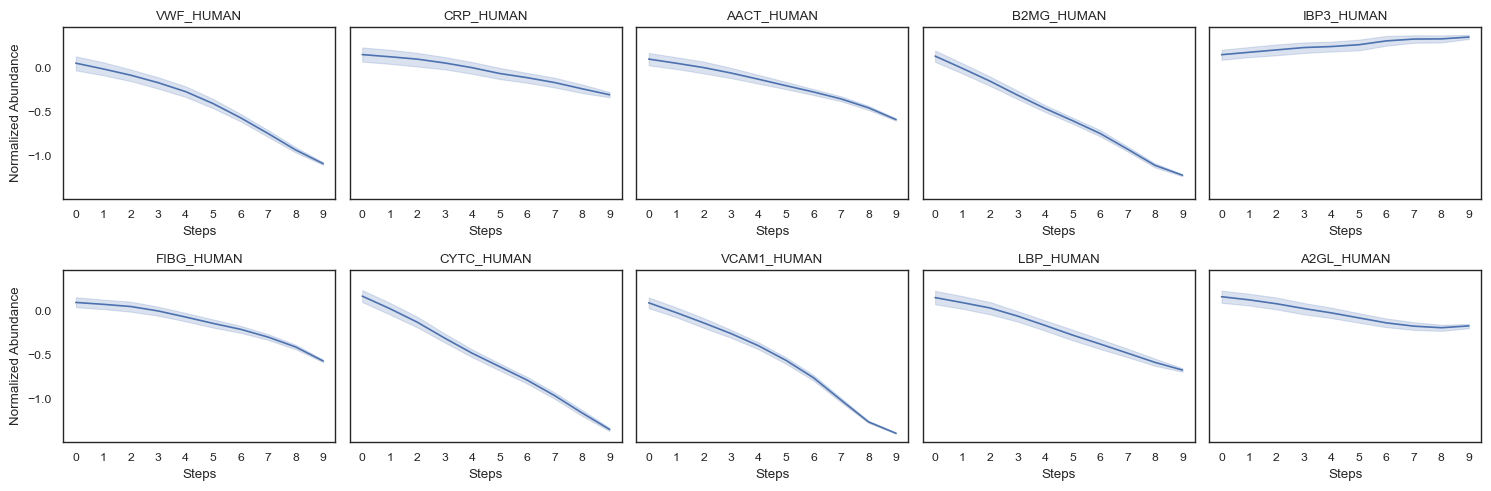

In [179]:
fig, axs = plt.subplots(
    nrows=2,
    ncols=5,
    sharey=True,
)

axs = axs.flatten()

for ax, col in enumerate(selected_features):
    sns.lineplot(
        data=results,
        x="Steps",
        y=col,
        ax=axs[ax]
        #hue="Future Organ Dysfunction",
    )

    axs[ax].set_ylabel("Normalized Abundance")
    axs[ax].set_title(col)
    axs[ax].set_xticks(np.arange(10))

fig.set_size_inches((15, 5))
plt.tight_layout()
plt.show()

<Axes: xlabel='Steps', ylabel='CRP_HUMAN'>

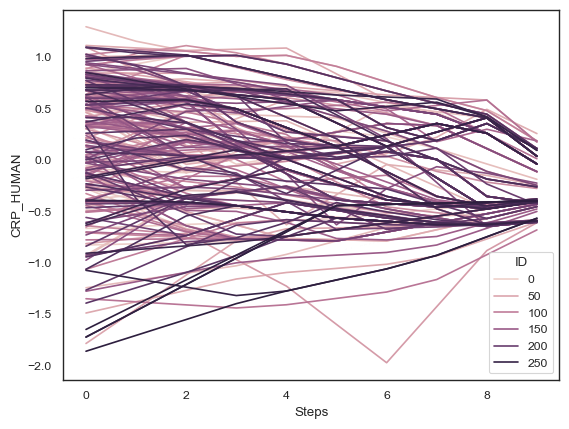

In [182]:
sns.lineplot(
    data=results,
    x="Steps",
    y="CRP_HUMAN",
    #ax=axs[ax]
    hue="ID",
)

In [186]:
results[]

,VWF_HUMAN,CRP_HUMAN,AACT_HUMAN,B2MG_HUMAN,IBP3_HUMAN,FIBG_HUMAN,CYTC_HUMAN,VCAM1_HUMAN,LBP_HUMAN,A2GL_HUMAN,Steps,ID,Future Organ Dysfunction,30 Day Mortality
0,0.331273,0.801892,0.475065,0.428112,0.466376,0.557777,0.787001,0.656286,0.664359,0.577309,0,0,0.8,0.2
1,0.450572,0.740938,0.515640,0.337245,0.511416,0.586157,0.644457,0.744027,0.707660,0.403825,1,0,0.8,0.2
2,0.462448,0.568334,0.430847,0.214954,0.541147,0.519495,0.455069,0.653722,0.611081,0.180035,2,0,0.8,0.2
3,0.259480,0.172433,0.095316,0.029817,0.540258,0.262747,0.171995,0.207326,0.234743,-0.144367,3,0,0.8,0.2
4,0.032863,0.028466,-0.024428,-0.184563,0.384436,0.111698,-0.090258,-0.113971,-0.048192,-0.198092,4,0,0.8,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,-1.052329,-1.165724,-1.285397,-0.835287,0.665904,-1.704123,-1.065279,-0.821500,-0.928251,-1.300190,5,261,0.5,0.1
6,-1.082638,-1.058241,-1.286920,-0.907541,0.731697,-1.349414,-1.148149,-0.910896,-0.913791,-1.366732,6,261,0.5,0.1
7,-1.127662,-0.926428,-1.228409,-1.001825,0.748257,-1.067045,-1.255650,-1.038397,-0.909233,-1.351816,7,261,0.5,0.1
8,-1.202115,-0.745955,-1.049828,-1.140166,0.666350,-0.929353,-1.412416,-1.242111,-0.924480,-1.173985,8,261,0.5,0.1


In [185]:
from sktime.clustering.dbscan import TimeSeriesDBSCAN

clst = TimeSeriesDBSCAN()

clst.fit()

'0.38.4'

<Axes: xlabel='Steps'>

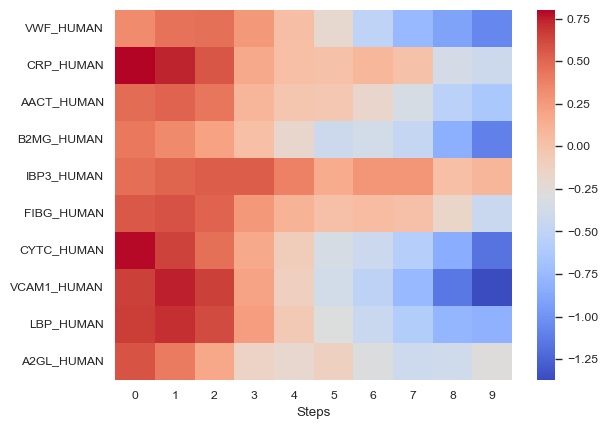

In [143]:
sns.heatmap(
    data=test2.astype(float),
    cmap="coolwarm"
)

<Axes: xlabel='Steps', ylabel='value'>

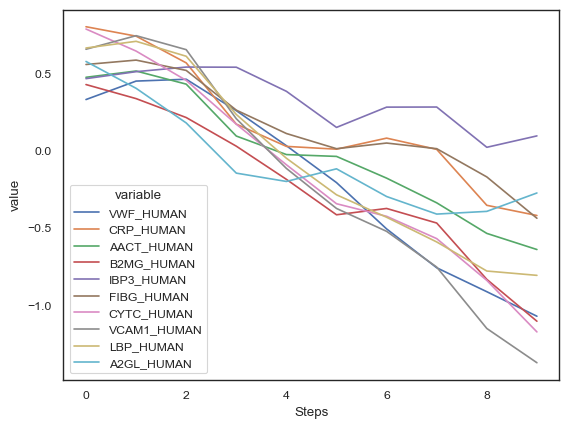

In [144]:
sns.lineplot(
    data=melted,
    x="Steps",
    y="value",
    hue="variable",
)

In [ ]:
source['sample']

In [ ]:
sample_graph.nodes[query_id]

In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt


X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

protein_estimated_sepsis, protein_linregress_results, protein_predictions, protein_corr, protein_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)


sns.regplot(
    data=protein_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color="k"
)

ax.set_title(
    f"R2: {protein_linregress_results.rvalue:.2f}"
)

sns.despine()

In [ ]:
df_estimator = DigitalFamilyBinary()

df_estimator.fit(X_subset, features=clinical_columns)
X_test['Sepsis Protein Prob'] = df_estimator.predict(
    X_test[clinical_columns], 
    features=clinical_columns, 
    target_column="sepsis_or_septic_shock"
)


X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

clinical_estimated_sepsis, clinical_linregress_results, clinical_predictions, clinical_corr, clinical_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)


sns.regplot(
    data=clinical_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color=".3",
    marker="x",
    line_kws=dict(color="k")
)

ax.set_title(
    f"R2: {clinical_linregress_results.rvalue:.2f}"
)

sns.despine()

In [ ]:
clinical_columns.extend(selected_features)
clinical_columns

In [ ]:
df_estimator = DigitalFamilyBinary()

df_estimator.fit(X_subset, features=clinical_columns)
X_test['Sepsis Protein Prob'] = df_estimator.predict(
    X_test[clinical_columns], 
    features=clinical_columns, 
    target_column="sepsis_or_septic_shock"
)

X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

combined_estimated_sepsis, combined_linregress_results, combined_predictions, combined_corr, combined_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)

sns.regplot(
    data=combined_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color="k"
)

ax.set_title(
    f"R2: {combined_linregress_results.rvalue:.2f}"
)

sns.despine()

In [ ]:
combined_estimated_sepsis

In [ ]:
protein_estimated_sepsis['Label'] = "Protein"
clinical_estimated_sepsis['Label'] = "Clinical"
combined_estimated_sepsis['Label'] = "Combined"

In [ ]:
protein_estimated_sepsis['Predictions'] = protein_predictions
clinical_estimated_sepsis['Predictions'] = clinical_predictions
combined_estimated_sepsis['Predictions'] = combined_predictions
combined_estimated_sepsis

In [ ]:
# protein_estimated_s = protein_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# protein_estimated_s['Label'] = "Protein"

In [ ]:
# clinical_estimated_s = clinical_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# clinical_estimated_s['Label'] = "Clinical"

In [ ]:
# combined_estimated_s = combined_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# combined_estimated_s['Label'] = "Combined"

In [ ]:
estimated_sepsis = pd.concat(
    [
        protein_estimated_sepsis,
        clinical_estimated_sepsis,
        combined_estimated_sepsis
    ]
)
estimated_sepsis

In [ ]:
#fig, ax = plt.subplots()

sns.set_theme(context="paper", style="white")

g = sns.lmplot(
    data=estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    hue="Label",
    row="Label",
    ci=95,
    palette="mako",
    scatter_kws={"color": "gray", "alpha": 0.5, "s": 5},
    line_kws={"lw": "3"},
    #scatter_kws={'alpha': 0.1, 's': 5},
    scatter=True,
    x_ci=95,
    x_jitter=0.01,
    #s=100,
    #ax=ax
)

# sns.lineplot(
#     data=estimated_sepsis,
#     x='Estimated Sepsis Rate',
#     y="Predictions",
#     hue="Label",
#     palette="mako",
#     lw=2,
#     ax=ax
# )

#g.axes[0].axline((0, 0), slope=1, color='k', linestyle='--')

sns.despine()

# ax.set_title(
#     f"R2: {combined_linregress_results.rvalue:.2f}\n
#     "
# )

g.figure.set_size_inches((4, 3))


In [ ]:
g.figure.savefig(
    "digital_family_sepsis.pdf", dpi=300, bbox_inches="tight"
)

In [ ]:
estimated_sepsis.to_csv(
    "digital_family_sepsis.tsv",
    sep="\t",
    index=False
)